In [88]:
import ExTRA as ex
import numpy as np
import astroquery
import astropy
import matplotlib.pyplot as plt

In [80]:
#Nu Oct as example
#HIP107089
hip_sss=np.array([5.6787539579,-1.3507009230,47.16,66.40,-239.10])
hip_iad=ex.hip_read("data/nu_oct/HIP107089_esa.d")[0] 
#[0] because in [1] is the measurement times and we dont need them for this


In [81]:
gaia_asc=(21 +41/60 +28.5420355132/3600 )*15 #deg
gaia_dec=(-77 -23/60 -24.031541832/3600) #deg


gaia_sss=np.array([np.radians(gaia_asc),np.radians(gaia_dec),51.5172,68.656,-250.044]) # in radians for propagator

v_rad_gaia=34.4 #km/s


In [82]:
propagator=ex.EpochPropagation()

In [ ]:
#Notice i give gaia model absolute position in RADIANS
#input of the propagator is [rad],[rad],[mas],[mas/yr],[mas/yr],[km/s],[yr],[yr]
gaia1991=np.array(propagator.propagate_astrometry(*gaia_sss,v_rad_gaia,1991.25,2016.0))[:-1]

### Now that we have gaia1991, we can correct our hipparcos residuals to it, so models between HIP astrometric data and gaia astrometric data are correct.

In [ ]:
gaia1991_deg=gaia1991.copy()
hip_sss_deg=hip_sss.copy()

#abs pos in degrees
gaia1991_deg[:2]=np.degrees(gaia1991[:2])
hip_sss_deg[:2]=np.degrees(hip_sss[:2])

#input of my abs res func is [deg],[deg],[mas],[mas/yr],[mas/yr]
abs_corrected=ex.abs_res(hip_iad[-2],gaia1991_deg,hip_sss_deg,hip_iad)
hip_iad_corrected=hip_iad.copy()
hip_iad_corrected[-2]=abs_corrected

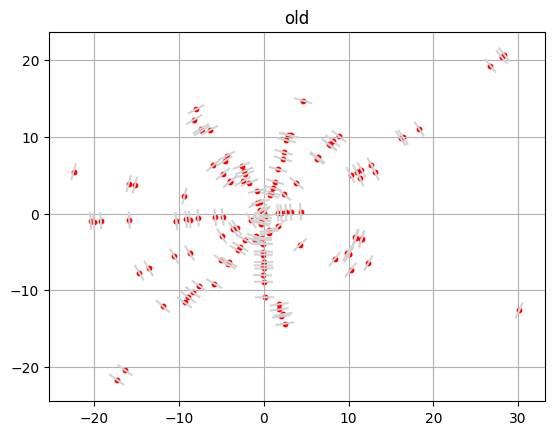

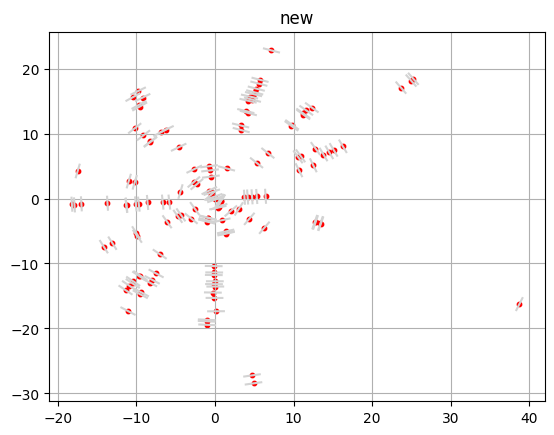

In [114]:
ex.plot_hip(*ex.hip_2d(hip_iad))
plt.title("old")
plt.grid()
plt.show()

plt.title("new")
ex.plot_hip(*ex.hip_2d(hip_iad_corrected))
plt.grid()
plt.show()

In [ ]:
print("old likelihood:",ex.loglikelihood(hip_iad[-2],hip_iad[-1],0),"[mas]**2")
print("new likelihood:",ex.loglikelihood(hip_iad_corrected[-2],hip_iad_corrected[-1],0),"[mas]**2")


old likelihood: 530.8247862687826 [mas]**2
new likelihood: 555.4981950746611 [mas]**2


### the likelihood got worse as expected, since hipparcos on its own used to have the optimal fit with the data available. the now new residuals are consistent with gaias single steller solution and can therefor easily be fit in combination. the single stellar solution fit corrections can now be applied to both of the residuals in the same way